# Práctica: Random Forest — Predicción de riesgo de deserción escolar

**Materia:** Extracción de Conocimiento en Bases de Datos
**Maestra:** MRySI. María Reina Zárate Nava
**Alumnos:** Sergio Aldair Carrillo Lome, Ángel de Jesús Martínez Rodríguez, Daniel Eduardo Pizarro Macuixtle, Fernando Torres Zonahua

En esta práctica se implementa el algoritmo **Random Forest** para predecir si un estudiante se encuentra en **riesgo de deserción escolar**, a partir de variables académicas y socioeconómicas. Se utiliza un conjunto de datos **sintético**, generado de forma controlada para simular un escenario realista.

## 1. Introducción

**Problemática:** La deserción escolar es un problema recurrente en instituciones educativas y detectarla a tiempo permite implementar estrategias de apoyo (tutorías, becas, orientación) antes de que un estudiante abandone sus estudios.

**Objetivo:** Entrenar un modelo de clasificación con **Random Forest** capaz de predecir, a partir de indicadores como asistencia, promedio, tareas entregadas y horas de trabajo, si un estudiante tiene **riesgo alto o bajo de deserción**.

## 2. Explicación del algoritmo: funcionamiento y lógica

**Random Forest** es un algoritmo de aprendizaje **supervisado**, utilizado tanto para **clasificación** (nuestro caso) como para regresión.

**¿Cómo funciona?**
1. Genera múltiples subconjuntos de los datos de entrenamiento mediante **muestreo bootstrap** (con reemplazo).
2. Construye un **árbol de decisión** independiente para cada subconjunto, eligiendo en cada división un subconjunto aleatorio de variables.
3. Cada árbol entrega su propia predicción de forma independiente.
4. El bosque combina los resultados: **votación mayoritaria** en clasificación (o promedio en regresión).

**Características:** reduce el sobreajuste (*overfitting*) frente a un solo árbol, es robusto ante datos ruidosos o incompletos, y permite estimar la **importancia de las variables**.

**Limitaciones:** menor interpretabilidad que un árbol individual y mayor costo computacional al entrenar muchos árboles.

**Aplicaciones reales:** detección de fraude, diagnóstico médico, sistemas de recomendación, riesgo crediticio y, como en esta práctica, predicción de deserción escolar.

## 3. Obtención de los datos y preprocesamiento

Los datos utilizados son **sintéticos**, generados con `numpy` a partir de distribuciones controladas para simular el comportamiento de estudiantes reales. Se define una regla de riesgo basada en asistencia, promedio y tareas entregadas, y se agrega ruido aleatorio para que el problema no sea trivial.

A continuación se importan las librerías necesarias y se genera el conjunto de datos.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style("whitegrid")
np.random.seed(42)

In [12]:
# Generación del dataset sintético
n = 500

asistencia = np.random.normal(80, 12, n).clip(30, 100)           # % de asistencia
promedio = np.random.normal(7.5, 1.2, n).clip(5, 10)              # promedio escolar
tareas_entregadas = np.random.normal(75, 15, n).clip(0, 100)      # % tareas entregadas
horas_trabajo = np.random.poisson(8, n).clip(0, 40)               # horas de trabajo/semana
distancia_casa = np.random.exponential(5, n).clip(0, 40)          # km al plantel
beca = np.random.binomial(1, 0.3, n)                              # 1 = cuenta con beca

# Puntaje de riesgo (a menor asistencia/promedio/tareas y mayor trabajo/distancia, mayor riesgo)
riesgo_score = (
    -0.04 * asistencia
    -0.5 * promedio
    -0.03 * tareas_entregadas
    +0.05 * horas_trabajo
    +0.03 * distancia_casa
    -0.6 * beca
    + np.random.normal(0, 1.5, n)  # ruido
)

umbral = np.percentile(riesgo_score, 65)
riesgo_desercion = (riesgo_score > umbral).astype(int)  # 1 = riesgo alto, 0 = riesgo bajo

df = pd.DataFrame({
    "asistencia": asistencia.round(1),
    "promedio": promedio.round(2),
    "tareas_entregadas": tareas_entregadas.round(1),
    "horas_trabajo": horas_trabajo,
    "distancia_casa": distancia_casa.round(1),
    "beca": beca,
    "riesgo_desercion": riesgo_desercion
})

df.head()

,asistencia,promedio,tareas_entregadas,horas_trabajo,distancia_casa,beca,riesgo_desercion
0,86.0,8.61,96.0,5,3.0,0,0
1,78.3,9.79,88.9,8,4.4,0,0
2,87.8,5.82,75.9,12,2.2,0,1
3,98.3,8.18,65.3,5,0.9,0,0
4,77.2,6.72,85.5,6,3.5,0,1


In [13]:
# Exploración y validación del preprocesamiento
print(df.info())
print("\nValores nulos por columna:\n", df.isnull().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   asistencia         500 non-null    float64
 1   promedio           500 non-null    float64
 2   tareas_entregadas  500 non-null    float64
 3   horas_trabajo      500 non-null    int32  
 4   distancia_casa     500 non-null    float64
 5   beca               500 non-null    int32  
 6   riesgo_desercion   500 non-null    int64  
dtypes: float64(4), int32(2), int64(1)
memory usage: 23.6 KB
None

Valores nulos por columna:
 asistencia           0
promedio             0
tareas_entregadas    0
horas_trabajo        0
distancia_casa       0
beca                 0
riesgo_desercion     0
dtype: int64


,asistencia,promedio,tareas_entregadas,horas_trabajo,distancia_casa,beca,riesgo_desercion
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,79.805800,7.535880,76.238800,7.856000,5.087200,0.284000,0.350000
std,11.150213,1.143159,14.411821,2.680604,5.151453,0.451388,0.477447
min,41.100000,5.000000,31.600000,1.000000,0.000000,0.000000,0.000000
25%,71.600000,6.787500,65.975000,6.000000,1.400000,0.000000,0.000000
50%,80.200000,7.530000,76.800000,8.000000,3.400000,0.000000,0.000000
75%,87.625000,8.282500,86.325000,10.000000,7.400000,1.000000,1.000000
max,100.000000,10.000000,100.000000,16.000000,35.700000,1.000000,1.000000


In [14]:
# Distribución de la variable objetivo
df["riesgo_desercion"].value_counts(normalize=True).mul(100).round(1)

riesgo_desercion
0    65.0
1    35.0
Name: proportion, dtype: float64

## 4. Importancia de las variables

**Variables predictoras (X):** `asistencia`, `promedio`, `tareas_entregadas`, `horas_trabajo`, `distancia_casa`, `beca`.

**Variable objetivo (y):** `riesgo_desercion` (0 = riesgo bajo, 1 = riesgo alto).

Antes de entrenar el modelo se revisa la correlación entre las variables predictoras y la variable objetivo, como primer acercamiento a su relevancia. La importancia real (medida por el propio Random Forest) se calculará más adelante, una vez entrenado el modelo.

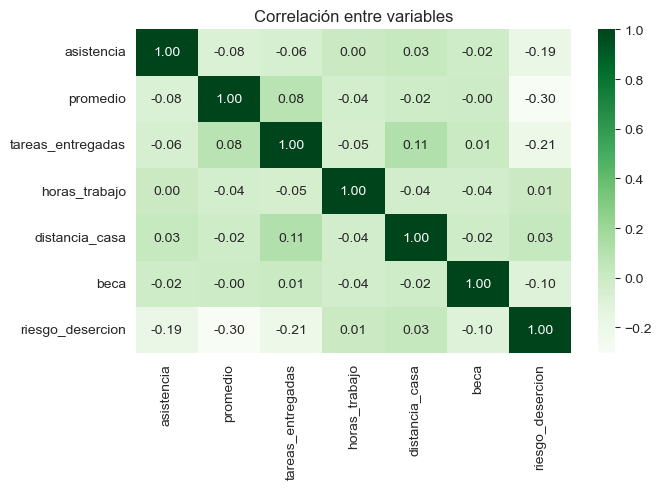

In [15]:
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(), annot=True, cmap="Greens", fmt=".2f")
plt.title("Correlación entre variables")
plt.tight_layout()
plt.show()

## 5. Separación de datos: entrenamiento y prueba

Se separa el conjunto de datos en **80% entrenamiento / 20% prueba**, usando `random_state=42` para hacer el experimento reproducible y `stratify=y` para mantener la misma proporción de clases en ambos conjuntos. El escalado de variables no es necesario para Random Forest, ya que su funcionamiento se basa en divisiones por umbral y no en distancias. El ajuste (`fit`) del modelo se realizará **únicamente** con los datos de entrenamiento, para evitar fuga de información (*data leakage*).

In [16]:
X = df.drop(columns=["riesgo_desercion"])
y = df["riesgo_desercion"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)
print("Proporción de clases (train):\n", y_train.value_counts(normalize=True))
print("Proporción de clases (test):\n", y_test.value_counts(normalize=True))

Entrenamiento: (400, 6)  Prueba: (100, 6)
Proporción de clases (train):
 riesgo_desercion
0    0.65
1    0.35
Name: proportion, dtype: float64
Proporción de clases (test):
 riesgo_desercion
0    0.65
1    0.35
Name: proportion, dtype: float64


## 6. Implementación del modelo

Se instancia un `RandomForestClassifier` de `scikit-learn` con:
- `n_estimators=200`: número de árboles en el bosque.
- `max_depth=6`: profundidad máxima de cada árbol, para evitar sobreajuste.
- `random_state=42`: reproducibilidad.

El modelo se entrena (`fit`) solo con los datos de entrenamiento y después se generan las predicciones sobre el conjunto de prueba.

In [17]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

y_pred = modelo_rf.predict(X_test)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## 7. Evaluación del modelo

Al tratarse de un problema de **clasificación**, se evalúa el desempeño con **accuracy, precision, recall y F1-score**, además de la **matriz de confusión**. También se calcula la **importancia real de las variables** obtenida por el modelo entrenado.

In [18]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=["Riesgo bajo", "Riesgo alto"]))

Accuracy:  0.760
Precision: 0.867
Recall:    0.371
F1-score:  0.520

Reporte de clasificación:

              precision    recall  f1-score   support

 Riesgo bajo       0.74      0.97      0.84        65
 Riesgo alto       0.87      0.37      0.52        35

    accuracy                           0.76       100
   macro avg       0.80      0.67      0.68       100
weighted avg       0.79      0.76      0.73       100



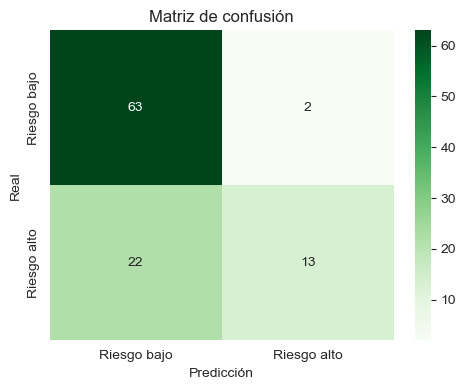

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Riesgo bajo", "Riesgo alto"],
            yticklabels=["Riesgo bajo", "Riesgo alto"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

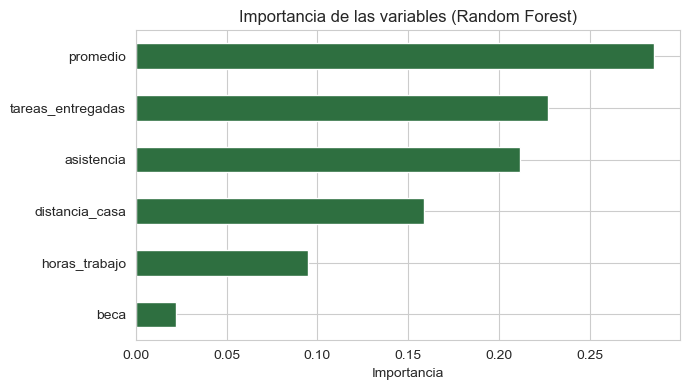

promedio             0.285329
tareas_entregadas    0.226826
asistencia           0.211647
distancia_casa       0.158856
horas_trabajo        0.095077
beca                 0.022265
dtype: float64

In [20]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(7,4))
importancias.plot(kind="barh", color="#2E6F40")
plt.title("Importancia de las variables (Random Forest)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

importancias.sort_values(ascending=False)

## 8. Implementación con datos nuevos

Se simulan **3 estudiantes nuevos**, no vistos por el modelo, respetando exactamente el mismo formato de entrada (mismas columnas y orden) que se usó en el entrenamiento. No requieren un preprocesamiento adicional, ya que Random Forest no necesita escalado. Se obtiene la predicción de clase y la probabilidad asociada.

In [21]:
estudiantes_nuevos = pd.DataFrame({
    "asistencia": [95, 60, 78],
    "promedio": [9.1, 6.0, 7.8],
    "tareas_entregadas": [90, 45, 70],
    "horas_trabajo": [0, 25, 10],
    "distancia_casa": [3, 15, 6],
    "beca": [1, 0, 0]
})

predicciones = modelo_rf.predict(estudiantes_nuevos)
probabilidades = modelo_rf.predict_proba(estudiantes_nuevos)[:, 1]

resultado = estudiantes_nuevos.copy()
resultado["riesgo_predicho"] = np.where(predicciones == 1, "Riesgo alto", "Riesgo bajo")
resultado["probabilidad_riesgo_alto"] = probabilidades.round(2)
resultado

,asistencia,promedio,tareas_entregadas,horas_trabajo,distancia_casa,beca,riesgo_predicho,probabilidad_riesgo_alto
0,95,9.1,90,0,3,1,Riesgo bajo,0.15
1,60,6.0,45,25,15,0,Riesgo alto,0.67
2,78,7.8,70,10,6,0,Riesgo bajo,0.41


## 9. Conclusiones

- El modelo de **Random Forest** logró clasificar el riesgo de deserción escolar con un desempeño adecuado, evaluado mediante accuracy, precision, recall y F1-score.
- La **matriz de confusión** permite identificar en qué clase el modelo comete más errores (falsos positivos o falsos negativos), lo cual es relevante en un contexto donde detectar a tiempo a un estudiante en riesgo es prioritario.
- La **importancia de variables** mostró qué factores (asistencia, promedio, tareas entregadas, etc.) influyen más en la predicción, aportando información útil para el diseño de estrategias de intervención.
- Como **limitación**, al usarse datos sintéticos, los resultados no reflejan directamente un caso real; para una aplicación en producción se requeriría un conjunto de datos histórico real de la institución.
- Como **mejora futura**, se podría ajustar los hiperparámetros del modelo (`n_estimators`, `max_depth`, `min_samples_split`) mediante validación cruzada (`GridSearchCV`) para optimizar aún más su desempeño.
- Como aprendizaje técnico, se reforzó el flujo completo de un proyecto de Machine Learning: obtención y preprocesamiento de datos, separación entrenamiento/prueba, entrenamiento, evaluación e implementación con datos nuevos.